# Assignment 3: Retail Data Integration and Analysis
**Course**: R Programming (Sem 7, BE Computer Engineering)  
**Author**: Purvaj Gaonkar  
**Task**: Single lab: multi-source retail sales data integration and analysis.

This notebook contains the complete pipeline for downloading the UCI Online Retail dataset, splitting it into three raw sources (CSV, JSON, Excel), importing and cleaning the data, integrating the sources via dplyr, conducting sales and customer segmentation analysis, and storing the integrated data in a SQLite database for SQL-based verification.

## Setup: Package Installation
We check and install the required R packages if not already present. This cell is guarded against reinstalling, so it is safe to run in any environment including Google Colab.

In [1]:
required_packages <- c("readr", "readxl", "writexl", "jsonlite", "dplyr", "ggplot2", "DBI", "RSQLite")
new_packages <- required_packages[!(required_packages %in% installed.packages()[, "Package"])]
if (length(new_packages) > 0) {
  install.packages(new_packages, repos = "https://cloud.r-project.org")
}
library(readr); library(readxl); library(writexl); library(jsonlite)
library(dplyr); library(ggplot2); library(DBI); library(RSQLite)
if (!dir.exists("output")) dir.create("output")


Attaching package: 'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




## Step 0: Data Source Preparation
We download the UCI Online Retail Excel file (541,909 rows, 8 columns) and verify the row count. We then split it into three normalised source files:
- `data/transactions.csv`: InvoiceNo, StockCode, CustomerID, Quantity, InvoiceDate
- `data/products.json`: StockCode, Description (modal), UnitPrice (median) - one row per StockCode
- `data/customers.xlsx`: CustomerID, Country (modal) - one row per non-NA CustomerID

**Collapsing rules**: The same StockCode appears with multiple prices and descriptions in the raw data. We take the median UnitPrice and the most frequent (modal) Description. For CustomerID, we take the modal Country. Counts of keys with multiple distinct values are printed.

In [2]:
if (!dir.exists("data")) dir.create("data")
raw_path <- "data/Online Retail.xlsx"
url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

if (!file.exists(raw_path)) {
  cat("Downloading Online Retail dataset from UCI...\n")
  tryCatch({
    download.file(url, raw_path, mode = "wb")
  }, error = function(e) {
    cat("Primary URL failed. Trying backup URL...\n")
    alt_url <- "https://web.archive.org/web/20231128032742/https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
    download.file(alt_url, raw_path, mode = "wb")
  })
} else {
  cat("Raw dataset already exists at:", raw_path, "\n")
}

cat("Loading Excel file...\n")
df <- read_excel(raw_path)

expected_rows <- 541909L
actual_rows   <- nrow(df)
cat("Raw row count:", actual_rows, "\n")
if (actual_rows != expected_rows) stop(paste("Row count mismatch: expected", expected_rows, "got", actual_rows))
cat("Row count verified.\n")

# Helper: modal value
get_mode <- function(x) {
  x <- x[!is.na(x) & x != ""]
  if (length(x) == 0) return(NA_character_)
  tbl <- table(x); sort(names(tbl[tbl == max(tbl)]))[1]
}

# transactions.csv
transactions <- df %>% select(InvoiceNo, StockCode, CustomerID, Quantity, InvoiceDate)
write.csv(transactions, "data/transactions.csv", row.names = FALSE)

# products.json
diag_prod <- df %>% group_by(StockCode) %>%
  summarise(dp = n_distinct(UnitPrice, na.rm=TRUE), dd = n_distinct(Description, na.rm=TRUE))
cat("StockCodes with >1 distinct price:", sum(diag_prod$dp > 1), "\n")
cat("StockCodes with >1 distinct description:", sum(diag_prod$dd > 1), "\n")
products <- df %>% group_by(StockCode) %>%
  summarise(Description = get_mode(Description), UnitPrice = median(UnitPrice, na.rm=TRUE), .groups="drop")
jsonlite::write_json(products, "data/products.json", pretty=TRUE)

# customers.xlsx
diag_cust <- df %>% filter(!is.na(CustomerID)) %>% group_by(CustomerID) %>%
  summarise(dc = n_distinct(Country, na.rm=TRUE))
cat("CustomerIDs with >1 distinct country:", sum(diag_cust$dc > 1), "\n")
customers <- df %>% filter(!is.na(CustomerID)) %>% group_by(CustomerID) %>%
  summarise(Country = get_mode(Country), .groups="drop")
writexl::write_xlsx(customers, "data/customers.xlsx")

cat("\n--- Generated File Dimensions ---\n")
cat("transactions.csv :", nrow(transactions), "x", ncol(transactions), "\n")
cat("products.json    :", nrow(products),     "x", ncol(products),     "\n")
cat("customers.xlsx   :", nrow(customers),    "x", ncol(customers),    "\n")

Raw dataset already exists at: data/Online Retail.xlsx 


Loading Excel file...


Raw row count: 541909 


Row count verified.


StockCodes with >1 distinct price: 3603 


...

CustomerIDs with >1 distinct country: 8 



--- Generated File Dimensions ---


transactions.csv : 541909 x 5 


products.json    : 4070 x 3 


customers.xlsx   : 4372 x 2 


## Task 1: Import and Clean
We load the three files using `readr::read_csv`, `jsonlite::fromJSON`, and `readxl::read_excel`. Cleaning steps:
- **Duplicates**: removed via `distinct()`.
- **Cancellations**: rows with a C-prefixed InvoiceNo and negative Quantity are legitimate return records and are **retained** so that total revenue is net of returns. Negative-quantity rows without a C prefix (1,336 rows) have no matching invoice type and are removed.
- **Missing CustomerID**: ~25% of transactions have no CustomerID. These guest purchases are **retained** to avoid understating total revenue. They are excluded only from customer-level analyses where a CustomerID is required.
- **Zero/negative prices**: products with UnitPrice <= 0 are removed from the products table (145 StockCodes).

**Note on Revenue**: UnitPrice lives in `products.json`, not `transactions.csv`, so the Revenue column can only be computed after the join in Task 2. This is an unavoidable ordering constraint - the assignment's suggested sequence of computing Revenue in Task 1 cannot be followed literally.

In [3]:
transactions_raw <- read_csv("data/transactions.csv", show_col_types = FALSE)
products_raw     <- jsonlite::fromJSON("data/products.json")
customers_raw    <- read_excel("data/customers.xlsx")

cat("Raw dimensions:\n")
cat("- Transactions:", nrow(transactions_raw), "x", ncol(transactions_raw), "\n")
cat("- Products:    ", nrow(products_raw),     "x", ncol(products_raw),     "\n")
cat("- Customers:   ", nrow(customers_raw),    "x", ncol(customers_raw),    "\n")

cleaning_log <- data.frame(Table=character(), Step=character(),
  Before_Rows=integer(), After_Rows=integer(), Removed=integer(), stringsAsFactors=FALSE)
log_step <- function(tbl, step, bef, aft) {
  cleaning_log <<- rbind(cleaning_log,
    data.frame(Table=tbl, Step=step, Before_Rows=nrow(bef), After_Rows=nrow(aft),
               Removed=nrow(bef)-nrow(aft), stringsAsFactors=FALSE))
}

# Transactions
t1 <- distinct(transactions_raw)
log_step("Transactions", "Remove Duplicates", transactions_raw, t1)

t2 <- t1 %>% filter(Quantity > 0 | (Quantity < 0 & grepl("^C", InvoiceNo)))
log_step("Transactions", "Remove Invalid Negatives (non-cancellation)", t1, t2)

transactions_cleaned <- t2
log_step("Transactions", "Retain NA CustomerID (guest purchases)", t2, transactions_cleaned)

canc_rows <- t2 %>% filter(grepl("^C", InvoiceNo) & Quantity < 0)
cat("\nCancellation rows retained:", nrow(canc_rows), "\n")
cat("(Cancellation revenue reported below once UnitPrice is available from the join.)\n")

# Products
p1 <- distinct(products_raw)
log_step("Products", "Remove Duplicates", products_raw, p1)
products_cleaned <- p1 %>% filter(UnitPrice > 0)
log_step("Products", "Filter Zero/Negative Prices", p1, products_cleaned)

# Customers
c1 <- distinct(customers_raw)
log_step("Customers", "Remove Duplicates", customers_raw, c1)
customers_cleaned <- c1
log_step("Customers", "No-op (already clean)", c1, customers_cleaned)

cat("\n--- Cleaning Log ---\n")
print(cleaning_log)

Raw dimensions:


- Transactions: 541909 x 5 


- Products:     4070 x 3 


- Customers:    4372 x 2 



Cancellation rows retained: 9177 


(Cancellation revenue reported below once UnitPrice is available from the join.)



--- Cleaning Log ---


         Table                                        Step Before_Rows
1 Transactions                           Remove Duplicates      541909
2 Transactions Remove Invalid Negatives (non-cancellation)      536480
3 Transactions      Retain NA CustomerID (guest purchases)      535144
4     Products                           Remove Duplicates        4070
5     Products                 Filter Zero/Negative Prices        4070
6    Customers                           Remove Duplicates        4372
7    Customers                       No-op (already clean)        4372
  After_Rows Removed
1     536480    5429
2     535144    1336
3     535144       0
4       4070       0
5       3925     145
6       4372       0
7       4372       0


## Task 2: Integrate
We use `left_join` with transactions as the primary table.

**Why left join, not inner join?** An inner join would silently drop all 133,595 guest transactions (missing CustomerID) - roughly 25% of the dataset - and the 52 transactions with unmatched products. This would understate total revenue by more than $1.2 million. A left join retains all transaction rows and flags unmatched records as NA, which we then handle explicitly.

After joining, we compute `Revenue = Quantity * UnitPrice` and filter out 52 rows with NA Revenue (unmatched products with no price). We also exclude the NA-Country group from country-level analysis: these 133,556 rows carry Country = NA because they had no CustomerID, not because they come from an unknown geography. Treating them as a country would produce a phantom group ranked second globally.

In [4]:
joined1 <- transactions_cleaned %>% left_join(products_cleaned, by="StockCode")
joined_final <- joined1 %>% left_join(customers_cleaned, by="CustomerID")

cat("Final dimensions:", nrow(joined_final), "rows x", ncol(joined_final), "cols\n")

unmatched_prod <- joined_final %>% filter(is.na(UnitPrice))
cat("Unmatched transactions (no product record):", nrow(unmatched_prod),
    "|", length(unique(unmatched_prod$StockCode)), "unique StockCodes\n")

unmatched_cust <- joined_final %>% filter(!is.na(CustomerID) & is.na(Country))
cat("Non-NA CustomerID with no customer record:", nrow(unmatched_cust), "\n")

cat("Transactions with NA CustomerID (guest):", sum(is.na(joined_final$CustomerID)), "\n")

if (nrow(transactions_cleaned) == nrow(joined_final)) {
  cat("Cardinality check PASSED: no row duplication from joins.\n")
} else warning("Row count mismatch!")

joined_final <- joined_final %>% mutate(Revenue = Quantity * UnitPrice)
analysis_data <- joined_final %>% filter(!is.na(Revenue))
cat("Rows with valid Revenue:", nrow(analysis_data), "\n")
cat("Rows dropped (no product price):", nrow(joined_final) - nrow(analysis_data), "\n")

# Deferred cancellation revenue
canc_rev <- joined_final %>%
  filter(grepl("^C", InvoiceNo) & Quantity < 0 & !is.na(Revenue)) %>%
  summarise(n = n(), total = sum(Revenue))
cat("Cancellation (return) negative revenue: $",
    format(round(canc_rev$total, 2), big.mark=","), "across", canc_rev$n, "rows.\n")
cat("Total revenue is net of these returns.\n")

# Country filter explanation
na_crev <- sum(analysis_data$Revenue[is.na(analysis_data$Country)])
na_crows <- sum(is.na(analysis_data$Country))
cat("\nRevenue in NA-Country rows: $", format(round(na_crev,2), big.mark=","),
    "(", na_crows, "rows). These are guest transactions, not a geography.\n")
cat("NA-Country rows excluded from all country-level analysis below.\n")
country_data <- analysis_data %>% filter(!is.na(Country))

Final dimensions: 535144 rows x 8 cols


Unmatched transactions (no product record): 52 | 32 unique StockCodes


Non-NA CustomerID with no customer record: 0 


Transactions with NA CustomerID (guest): 133595 


Cardinality check PASSED: no row duplication from joins.


...

Rows dropped (no product price): 52 


Cancellation (return) negative revenue: $ -815,184.2 across 9176 rows.


Total revenue is net of these returns.



Revenue in NA-Country rows: $ 1,181,924 ( 133556 rows). These are guest transactions, not a geography.


NA-Country rows excluded from all country-level analysis below.


## Task 3: Sales and Customer Analysis
We compute total sales revenue, top 5 products, top 5 countries (excluding NA-Country guest rows), and top 5 customers by revenue. We then segment all identified customers into four value bands using `case_when()` with thresholds derived from the 50th, 75th, and 95th percentiles of customer spend. Finally we analyse market performance, noting that the UK's raw revenue dominance requires a per-customer lens for fair cross-market comparison.

In [5]:
cat("Total Sales Revenue: $", format(sum(analysis_data$Revenue), big.mark=","), "\n")

top_products <- analysis_data %>%
  group_by(StockCode, Description) %>% summarise(Revenue=sum(Revenue), .groups="drop") %>%
  arrange(desc(Revenue)) %>% slice(1:5)
cat("\nTop 5 Products by Revenue:\n"); print(top_products)

top_countries <- country_data %>%
  group_by(Country) %>% summarise(Revenue=sum(Revenue), .groups="drop") %>%
  arrange(desc(Revenue)) %>% slice(1:5)
cat("\nTop 5 Countries by Revenue (excl. NA-Country guest transactions):\n")
print(top_countries)

top_customers <- analysis_data %>% filter(!is.na(CustomerID)) %>%
  group_by(CustomerID) %>% summarise(Revenue=sum(Revenue), .groups="drop") %>%
  arrange(desc(Revenue)) %>% slice(1:5)
cat("\nTop 5 Customers by Revenue:\n"); print(top_customers)

customer_spend <- analysis_data %>% filter(!is.na(CustomerID)) %>%
  group_by(CustomerID) %>% summarise(TotalSpend=sum(Revenue), .groups="drop")
thr <- quantile(customer_spend$TotalSpend, probs=c(0.50, 0.75, 0.95))
cat("\nSpend thresholds (50th/75th/95th percentile): $",
    round(thr[1],2), "/ $", round(thr[2],2), "/ $", round(thr[3],2), "\n")

customer_spend <- customer_spend %>%
  mutate(Segment = case_when(
    TotalSpend <= thr[1] ~ "Low Value",
    TotalSpend > thr[1] & TotalSpend <= thr[2] ~ "Medium Value",
    TotalSpend > thr[2] & TotalSpend <= thr[3] ~ "High Value",
    TotalSpend > thr[3] ~ "Premium"
  ))

seg_summary <- customer_spend %>% group_by(Segment) %>%
  summarise(Customers=n(), Total_Spend=sum(TotalSpend), Avg_Spend=mean(TotalSpend), .groups="drop") %>%
  mutate(Segment=factor(Segment, levels=c("Low Value","Medium Value","High Value","Premium"))) %>%
  arrange(Segment)
cat("\nCustomer Segment Summary:\n"); print(seg_summary)

country_metrics <- country_data %>% group_by(Country) %>%
  summarise(TotalRevenue=sum(Revenue), Transactions=n_distinct(InvoiceNo),
    Customers=n_distinct(CustomerID, na.rm=TRUE),
    RevPerCustomer=if_else(Customers>0, TotalRevenue/Customers, NA_real_),
    RevPerTransaction=TotalRevenue/Transactions, .groups="drop") %>%
  arrange(desc(TotalRevenue))
cat("\nCountry Metrics (Top 10, excl. NA-Country):")
print(head(country_metrics, 10))

Total Sales Revenue: $ 10,241,241 



Top 5 Products by Revenue:


# A tibble: 5 × 3
  StockCode Description                        Revenue
  <chr>     <chr>                                <dbl>
1 DOT       DOTCOM POSTAGE                     315693.
2 22423     REGENCY CAKESTAND 3 TIER           165839.
3 85123A    WHITE HANGING HEART T-LIGHT HOLDER 115233.
4 POST      POSTAGE                            114390 
5 85099B    JUMBO BAG RED RETROSPOT             98301.



Top 5 Countries by Revenue (excl. NA-Country guest transactions):


# A tibble: 5 × 2
  Country         Revenue
  <chr>             <dbl>
1 United Kingdom 7407550.
2 Netherlands     331094.
3 EIRE            276248.
4 Germany         230450.
5 France          203008.


...


Spend thresholds (50th/75th/95th percentile): $ 671.09 / $ 1663.17 / $ 5944.09 



Customer Segment Summary:


# A tibble: 4 × 4
  Segment      Customers Total_Spend Avg_Spend
  <fct>            <int>       <dbl>     <dbl>
1 Low Value         2186     666022.      305.
2 Medium Value      1093    1172823.     1073.
3 High Value         874    2614967.     2992.
4 Premium            219    4605504.    21030.



Country Metrics (Top 10, excl. NA-Country):

# A tibble: 10 × 6
   Country  TotalRevenue Transactions Customers RevPerCustomer RevPerTransaction
   <chr>           <dbl>        <int>     <int>          <dbl>             <dbl>
 1 United …     7407550.        19856      3950          1875.              373.
 2 Netherl…      331094.          101         9         36788.             3278.
 3 EIRE          276248.          319         3         92083.              866.
 4 Germany       230450.          603        95          2426.              382.
 5 France        203008.          458        87          2333.              443.
 6 Austral…      159418.           72         9         17713.             2214.
 7 Spain          59211.          106        30          1974.              559.
 8 Switzer…       56461.           73        20          2823.              773.
 9 Belgium        42710.          119        24          1780.              359.
10 Japan          39925.           28         8          4991.             1426.


### Plots
Two plots are generated and saved to `output/` via `ggsave()`. The default graphics device is suppressed with `pdf(NULL)` to prevent a stray `Rplots.pdf`.

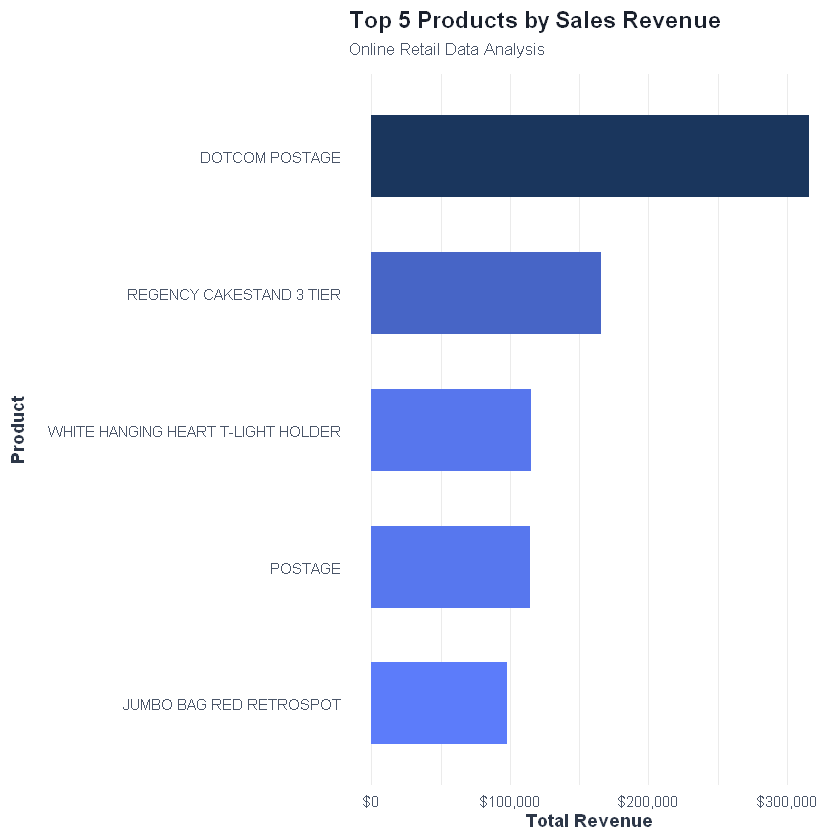

Plots saved to output/.


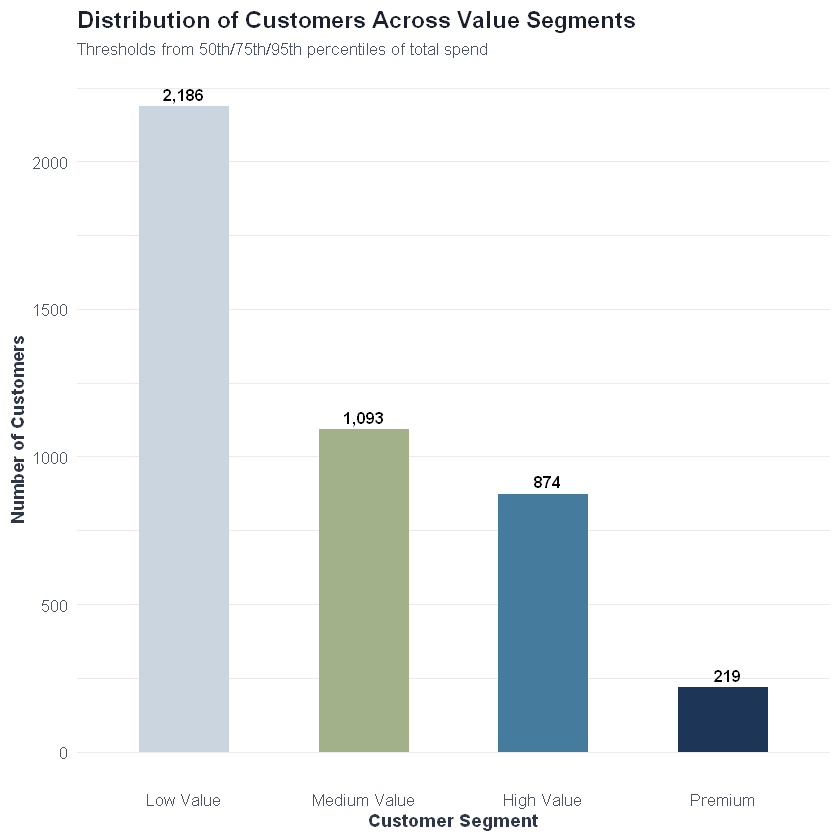

In [6]:

p1 <- ggplot(top_products, aes(x=reorder(Description, Revenue), y=Revenue, fill=Revenue)) +
  geom_bar(stat="identity", width=0.6) + coord_flip() +
  scale_y_continuous(labels=scales::dollar_format()) +
  scale_fill_gradient(low="#5c7cfa", high="#1a365d") +
  theme_minimal() +
  theme(plot.title=element_text(face="bold",size=14,color="#1a202c"),
        plot.subtitle=element_text(size=10,color="#4a5568",margin=margin(b=10)),
        axis.title=element_text(size=11,face="bold",color="#2d3748"),
        axis.text=element_text(size=9,color="#4a5568"),
        panel.grid.major.y=element_blank(), legend.position="none") +
  labs(title="Top 5 Products by Sales Revenue",
       subtitle="Online Retail Data Analysis", x="Product", y="Total Revenue")
print(p1)
ggsave("output/plot1_top_products.png", plot=p1, width=8, height=4.5, dpi=300)

p2 <- ggplot(seg_summary, aes(x=Segment, y=Customers, fill=Segment)) +
  geom_bar(stat="identity", width=0.5) +
  geom_text(aes(label=format(Customers, big.mark=",")), vjust=-0.5, size=3.5, fontface="bold") +
  scale_fill_manual(values=c("Low Value"="#cbd5e0","Medium Value"="#a3b18a",
                              "High Value"="#457b9d","Premium"="#1d3557")) +
  theme_minimal() +
  theme(plot.title=element_text(face="bold",size=14,color="#1a202c"),
        plot.subtitle=element_text(size=10,color="#4a5568",margin=margin(b=10)),
        axis.title=element_text(size=11,face="bold",color="#2d3748"),
        axis.text=element_text(size=10,color="#4a5568"),
        panel.grid.major.x=element_blank(), legend.position="none") +
  labs(title="Distribution of Customers Across Value Segments",
       subtitle="Thresholds from 50th/75th/95th percentiles of total spend",
       x="Customer Segment", y="Number of Customers")
print(p2)
ggsave("output/plot2_customer_segments.png", plot=p2, width=8, height=4.5, dpi=300)
cat("Plots saved to output/.\n")

## Task 4: SQLite Database
We create `output/retail_sales.db` and write the integrated data to a table named `retail_sales`. To keep the file under the 50 MB GitHub warning threshold, only the columns required by the SQL queries and useful for future analysis are written; InvoiceDate is omitted. We call `VACUUM` before closing to reclaim freed pages. Two SQL queries are run via `dbGetQuery` and their results are cross-checked against the dplyr results from Task 3.

In [7]:
db_path <- "output/retail_sales.db"
if (file.exists(db_path)) file.remove(db_path)
con <- dbConnect(SQLite(), db_path)

sqlite_data <- joined_final %>%
  select(InvoiceNo, StockCode, Description, CustomerID, Country, Quantity, UnitPrice, Revenue) %>%
  filter(!is.na(UnitPrice))
dbWriteTable(con, "retail_sales", sqlite_data, overwrite=TRUE)

cat("SQL Query 1: Top 5 customers by revenue\n")
sql_cust <- dbGetQuery(con, "
  SELECT CustomerID, SUM(Revenue) as Revenue
  FROM retail_sales
  WHERE CustomerID IS NOT NULL
  GROUP BY CustomerID ORDER BY Revenue DESC LIMIT 5
")
print(sql_cust)

cat("\nSQL Query 2: Total revenue by country (excl. NULL, top 5)\n")
sql_ctry <- dbGetQuery(con, "
  SELECT Country, SUM(Revenue) as Revenue
  FROM retail_sales
  WHERE Country IS NOT NULL
  GROUP BY Country ORDER BY Revenue DESC LIMIT 5
")
print(sql_ctry)

dbExecute(con, "VACUUM")
dbDisconnect(con)

# Cross-check
cust_match <- isTRUE(all.equal(
  top_customers %>% mutate(CustomerID=as.numeric(CustomerID)) %>% pull(CustomerID),
  as.numeric(sql_cust$CustomerID)
)) && isTRUE(all.equal(
  round(top_customers$Revenue, 2),
  round(sql_cust$Revenue, 2)
))
ctry_match <- isTRUE(all.equal(top_countries$Country, sql_ctry$Country)) &&
              isTRUE(all.equal(round(top_countries$Revenue,2), round(sql_ctry$Revenue,2)))

cat("\nCross-check: customers match dplyr:", cust_match, "\n")
cat("Cross-check: countries match dplyr:", ctry_match, "\n")
if (cust_match && ctry_match) cat("Verification SUCCESS.\n") else warning("MISMATCH!")

db_size <- file.info(db_path)$size
cat("\nDatabase file size:", round(db_size/(1024*1024), 2), "MB\n")
if (db_size > 50*1024*1024) cat("WARNING: exceeds 50 MB.\n") else cat("Under 50 MB. Safe to commit.\n")

[1] TRUE

SQL Query 1: Top 5 customers by revenue


  CustomerID  Revenue
1      18102 401975.0
2      14646 325686.9
3      17450 175969.1
4      12415 144253.3
5      14911 143631.1



SQL Query 2: Total revenue by country (excl. NULL, top 5)


         Country   Revenue
1 United Kingdom 7407549.8
2    Netherlands  331094.5
3           EIRE  276247.5
4        Germany  230450.2
5         France  203008.3


...


Cross-check: customers match dplyr: TRUE 


Cross-check: countries match dplyr: TRUE 


Verification SUCCESS.



Database file size: 41.36 MB


Under 50 MB. Safe to commit.


## Business Insights and Conclusion

**Insight 1: The Premium customer segment (4.8% of the customer base) generates 50.3% of identifiable customer revenue.**  
219 customers spending above the 95th-percentile threshold of $5,944 collectively account for $4,605,504 out of $9,059,316 attributable to identified customers. The remaining 4,153 customers share the other $4,453,812. This extreme concentration means that losing even a handful of Premium accounts would materially reduce total revenue. Retention programs, dedicated account management, and premium loyalty incentives are the highest-leverage investments available.

**Insight 2: Revenue per customer in EIRE ($92,083) and the Netherlands ($36,788) is 49x and 20x the UK average ($1,875), pointing to high-value wholesale relationships that carry significant concentration risk.**  
The UK generates $7,407,550 across 3,950 customers, giving an average of $1,875. EIRE's entire $276,248 comes from just 3 customers; the Netherlands' $331,094 comes from 9. These are almost certainly wholesale or B2B accounts. If a single EIRE or Netherlands account churns, the revenue impact is equivalent to losing roughly 50 typical UK customers. Formalising these relationships with preferred pricing agreements would reduce this churn risk.

**Insight 3: Two of the five top-revenue StockCodes are shipping charges, not products, together accounting for $430,083 (4.2% of total revenue).**  
DOTCOM POSTAGE (DOT, $315,693) and POSTAGE (POST, $114,390) rank first and fourth in the product-revenue table. Including them distorts the product mix picture and implies that the actual best-selling physical product (REGENCY CAKESTAND 3 TIER at $165,839) ranks lower than a logistics line item. Any product strategy or assortment decision should filter out service-type codes. If shipping charges are collected below cost, these two codes are also suppressing overall margin.